# CNN Training Notebook

### 0. Import Library & Dataset

In [ ]:
import os
import sys
import itertools
import time
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, classification_report
import tensorflow as tf

try:
    _nb_dir = Path(__vsc_ipynb_file__).parent
except NameError:
    _nb_dir = Path(os.getcwd())

_root = _nb_dir
while not (_root / 'src').exists() and _root != _root.parent:
    _root = _root.parent

if not (_root / 'src').exists():
    _wsl = Path('/mnt/c/Users/nazwa/Coding/Semester-6/Tubes2_ML_2_Karyawan_Tetap')
    _root = _wsl if _wsl.exists() else None
    if _root is None:
        raise RuntimeError(f"Tidak bisa menemukan project root! CWD: {os.getcwd()}")

if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
os.chdir(_root)

from src.cnn.visualize import plot_feature_maps, plot_grad_cam, plot_grad_cam_grid
from src.cnn.model import CNNFromScratch

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

print('TF: ', tf.__version__)
print('GPU: ', gpus)

I0000 00:00:1778756958.893227     501 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778756959.430488     501 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778756961.987033     501 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TF:  2.21.0
GPU:  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
src = Path(os.getcwd())

while not (src / 'src').exists() and src != src.parent:
    src = src.parent

if not (src / 'src').exists():
    wsl_path = Path('/mnt/c/Users/nazwa/Coding/Semester-6/Tubes2_ML_2_Karyawan_Tetap')
    if wsl_path.exists():
        src = wsl_path
    else:
        raise RuntimeError(f"Tidak bisa menemukan project root! CWD: {os.getcwd()}")

sys.path.insert(0, str(src))
os.chdir(src)
print("Project root:", src)

Project root: /mnt/c/Users/nazwa/Coding/Semester-6/Tubes2_ML_2_Karyawan_Tetap


In [4]:
DATA_DIR = src / 'data' / 'cnn'
MODEL_DIR = src / 'models' / 'cnn'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_DIR = DATA_DIR / 'seg_train' / 'seg_train'
TEST_DIR  = DATA_DIR / 'seg_test' / 'seg_test'

print("TRAIN_DIR:", TRAIN_DIR)
print("Exists:", TRAIN_DIR.exists())

TRAIN_DIR: /mnt/c/Users/nazwa/Coding/Semester-6/Tubes2_ML_2_Karyawan_Tetap/data/cnn/seg_train/seg_train
Exists: True


In [5]:
import os
print("CWD:", os.getcwd())
print("TRAIN_DIR:", TRAIN_DIR)
print("Exists:", TRAIN_DIR.exists())


CWD: /mnt/c/Users/nazwa/Coding/Semester-6/Tubes2_ML_2_Karyawan_Tetap
TRAIN_DIR: /mnt/c/Users/nazwa/Coding/Semester-6/Tubes2_ML_2_Karyawan_Tetap/data/cnn/seg_train/seg_train
Exists: True


### 1. Load Dataset

In [6]:
CLASSES = []

for iterdir in TRAIN_DIR.iterdir():
    if iterdir.is_dir():
        CLASSES.append(iterdir.name)

CLASSES.sort()
print('Classes are ', CLASSES)

# 80:20 Split untuk Train & Test dataset
# Define Variables
IMG_SIZE = 100
BATCH_SIZE = 32
EPOCHS = 20
NUM_CLASSES = 6

# 1. Train
train_split_ = tf.keras.utils.image_dataset_from_directory(TRAIN_DIR, 
                                                           image_size = (IMG_SIZE, IMG_SIZE),
                                                           batch_size = BATCH_SIZE,
                                                           label_mode = 'int',
                                                           seed = 42,
                                                           class_names = CLASSES,
                                                           validation_split  = 0.2,
                                                           subset = 'training',
                                                           )

# 2. Validation
validate_split_ = tf.keras.utils.image_dataset_from_directory(TRAIN_DIR,
                                                              image_size = (IMG_SIZE, IMG_SIZE),
                                                              batch_size = BATCH_SIZE,
                                                              label_mode = 'int',
                                                              seed = 42,
                                                              class_names = CLASSES,
                                                              validation_split = 0.2,
                                                              subset = 'validation',
                                                              )

# 3. Test
test_split_ = tf.keras.utils.image_dataset_from_directory(TEST_DIR,
                                                           image_size = (IMG_SIZE, IMG_SIZE),
                                                           batch_size = BATCH_SIZE,
                                                           label_mode = 'int',
                                                           shuffle = False,
                                                           class_names = CLASSES,
                                                           )

norm = tf.keras.layers.Rescaling(1./255)
train_ds = train_split_.map(lambda x,y: (norm(x), y)).cache().prefetch(tf.data.AUTOTUNE)
val_ds = validate_split_.map(lambda x,y: (norm(x), y)).cache().prefetch(tf.data.AUTOTUNE)
test_ds = test_split_.map(lambda x,y: (norm(x), y)).cache().prefetch(tf.data.AUTOTUNE)

label_list = []
for gambar, label in test_ds:
    label_numpy = label.numpy()

    label_list.append(label_numpy)

y_test = np.concatenate(label_list)
print(f'Train: {len(train_ds)}')
print(f'Validation: {len(val_ds)}')
print(f'Test: {len(y_test)}')

Classes are  ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Found 14034 files belonging to 6 classes.
Using 11228 files for training.


I0000 00:00:1778757011.265075     501 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1763 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Found 14034 files belonging to 6 classes.
Using 2806 files for validation.
Found 3000 files belonging to 6 classes.
Train: 351
Validation: 88
Test: 3000


### 2. CNN

In [7]:
GRID = {
    'n_conv':  [2, 4],
    'filters': [[32, 64], [64, 128]],
    'k_size': [3, 5],
    'pool': ['max', 'avg']
}

configs = list(itertools.product(GRID['n_conv'],
                                 GRID['filters'],
                                 GRID['k_size'],
                                 GRID['pool']
                                 ))

for i, (n, fltrs, krnl, pl) in enumerate(configs):
    print(f' [{i}] n_conv = {n}, filters={fltrs}, k_size={krnl}, pool={pl}')

 [0] n_conv = 2, filters=[32, 64], k_size=3, pool=max
 [1] n_conv = 2, filters=[32, 64], k_size=3, pool=avg
 [2] n_conv = 2, filters=[32, 64], k_size=5, pool=max
 [3] n_conv = 2, filters=[32, 64], k_size=5, pool=avg
 [4] n_conv = 2, filters=[64, 128], k_size=3, pool=max
 [5] n_conv = 2, filters=[64, 128], k_size=3, pool=avg
 [6] n_conv = 2, filters=[64, 128], k_size=5, pool=max
 [7] n_conv = 2, filters=[64, 128], k_size=5, pool=avg
 [8] n_conv = 4, filters=[32, 64], k_size=3, pool=max
 [9] n_conv = 4, filters=[32, 64], k_size=3, pool=avg
 [10] n_conv = 4, filters=[32, 64], k_size=5, pool=max
 [11] n_conv = 4, filters=[32, 64], k_size=5, pool=avg
 [12] n_conv = 4, filters=[64, 128], k_size=3, pool=max
 [13] n_conv = 4, filters=[64, 128], k_size=3, pool=avg
 [14] n_conv = 4, filters=[64, 128], k_size=5, pool=max
 [15] n_conv = 4, filters=[64, 128], k_size=5, pool=avg


In [8]:
def build_cnn(n_conv, filters, k_size, pool):
    if pool == 'max':
        PoolLayer = tf.keras.layers.MaxPooling2D
    else:
        PoolLayer = tf.keras.layers.AveragePooling2D

    name_model = f'cnn_c{n_conv}_k{k_size}_{pool}'
    model = tf.keras.Sequential(name=name_model)
    model.add(tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)))

    for i in range (n_conv):
        fltr = filters[i % len(filters)]
        model.add(tf.keras.layers.Conv2D(fltr, k_size, activation='relu', padding='same'))
        model.add(PoolLayer(2, 2))

    model.add(tf.keras.layers.GlobalAveragePooling2D())
    model.add(tf.keras.layers.Dense(128, activation='relu'))
    model.add(tf.keras.layers.Dense(NUM_CLASSES, activation='softmax'))

    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [9]:
HIST_PATH = MODEL_DIR / 'histories.json'
history = {}

if HIST_PATH.exists():
    with open(HIST_PATH) as filepath:
        history = json.load(filepath)

result_list = []
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

for i, (n_conv, fltrs, krnl, pl) in enumerate(configs):
    tag = f'c{n_conv}_f{"_".join(map(str,fltrs))}_k{krnl}_{pl}'

    save_path = MODEL_DIR / f'arch_{i:02d}_{tag}.h5'
    print(f'[{i+1}/16] {tag}', end=' ... ')

    if save_path.exists():
        model = tf.keras.models.load_model(save_path)
        print('model loaded (1)')

    else:
        model = build_cnn(n_conv, fltrs, krnl, pl)
        hist = model.fit(train_ds, epochs=EPOCHS, validation_data=val_ds, callbacks=[early_stop], verbose=0)
        
        model.save(save_path)
        history[tag] = hist.history

        with open(HIST_PATH, 'w') as filepath:
            json.dump(history, filepath)
        print(f'trained {len(hist.history["loss"])} epochs')

    y_pred = model.predict(test_ds, verbose=0).argmax(1)
    f1 = f1_score(y_test, y_pred, average='macro')

    result_list.append({
        'idx': i, 'tag': tag,
        'n_conv': n_conv, 'filters': str(fltrs),
        'k_size': krnl, 'pool': pl,
        'f1_macro': round(f1, 4),
        'params': model.count_params(),
    })
    print(f'  - F1: {f1:.4f}')

with open(MODEL_DIR / 'results.json', 'w') as fp:
    json.dump(result_list, fp, indent=2)
print('\nDone')  


[1/16] c2_f32_64_k3_max ... 

I0000 00:00:1778757021.026694     642 service.cc:153] XLA service 0x72cd0c0321c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778757021.026743     642 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.22.0)
I0000 00:00:1778757021.101767     642 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778757021.503199     642 cuda_dnn.cc:461] Loaded cuDNN version 92200
I0000 00:00:1778757021.522420     642 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1900__.31
I0000 00:00:1778757027.561517     642 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
I0000 00:00:1778757036.305876     639 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_190

trained 13 epochs
  - F1: 0.7041
[2/16] c2_f32_64_k3_avg ... 

I0000 00:00:1778757129.334248     641 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_27978__.23
I0000 00:00:1778757135.470496     640 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_27978__.23


trained 5 epochs
  - F1: 0.4729
[3/16] c2_f32_64_k5_max ... 

...

trained 5 epochs
  - F1: 0.5491
[15/16] c4_f64_128_k5_max ... 

I0000 00:00:1778758107.326095     641 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_212303__.49
I0000 00:00:1778758132.915297     640 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_212303__.49


trained 5 epochs
  - F1: 0.5494
[16/16] c4_f64_128_k5_avg ... 

I0000 00:00:1778758223.009080     640 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_224782__.33
I0000 00:00:1778758240.496224     640 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_224782__.33


trained 5 epochs
  - F1: 0.5127

Done


### 3. Hasil Training

In [10]:
df = pd.DataFrame(result_list).sort_values('f1_macro', ascending=False).reset_index(drop=True)
display(df[['tag','n_conv','filters','k_size','pool','f1_macro','params']])

best_row = df.iloc[0]
print(f'\nArsitektur terbaik: {best_row["tag"]} (F1={best_row["f1_macro"]:.4f})')

,tag,n_conv,filters,k_size,pool,f1_macro,params
0,c4_f32_64_k3_max,4,"[32, 64]",3,max,0.8536,65446
1,c2_f32_64_k3_max,2,"[32, 64]",3,max,0.7041,28486
2,c4_f64_128_k3_max,4,"[64, 128]",3,max,0.6277,240582
3,c4_f32_64_k5_max,4,"[32, 64]",5,max,0.5771,165286
4,c4_f32_64_k5_avg,4,"[32, 64]",5,avg,0.5574,165286
5,c4_f64_128_k5_max,4,"[64, 128]",5,max,0.5494,636870
6,c4_f64_128_k3_avg,4,"[64, 128]",3,avg,0.5491,240582
7,c2_f32_64_k5_max,2,"[32, 64]",5,max,0.5481,62790
8,c2_f64_128_k5_max,2,"[64, 128]",5,max,0.5409,227078
9,c2_f64_128_k5_avg,2,"[64, 128]",5,avg,0.5334,227078



Arsitektur terbaik: c4_f32_64_k3_max (F1=0.8536)


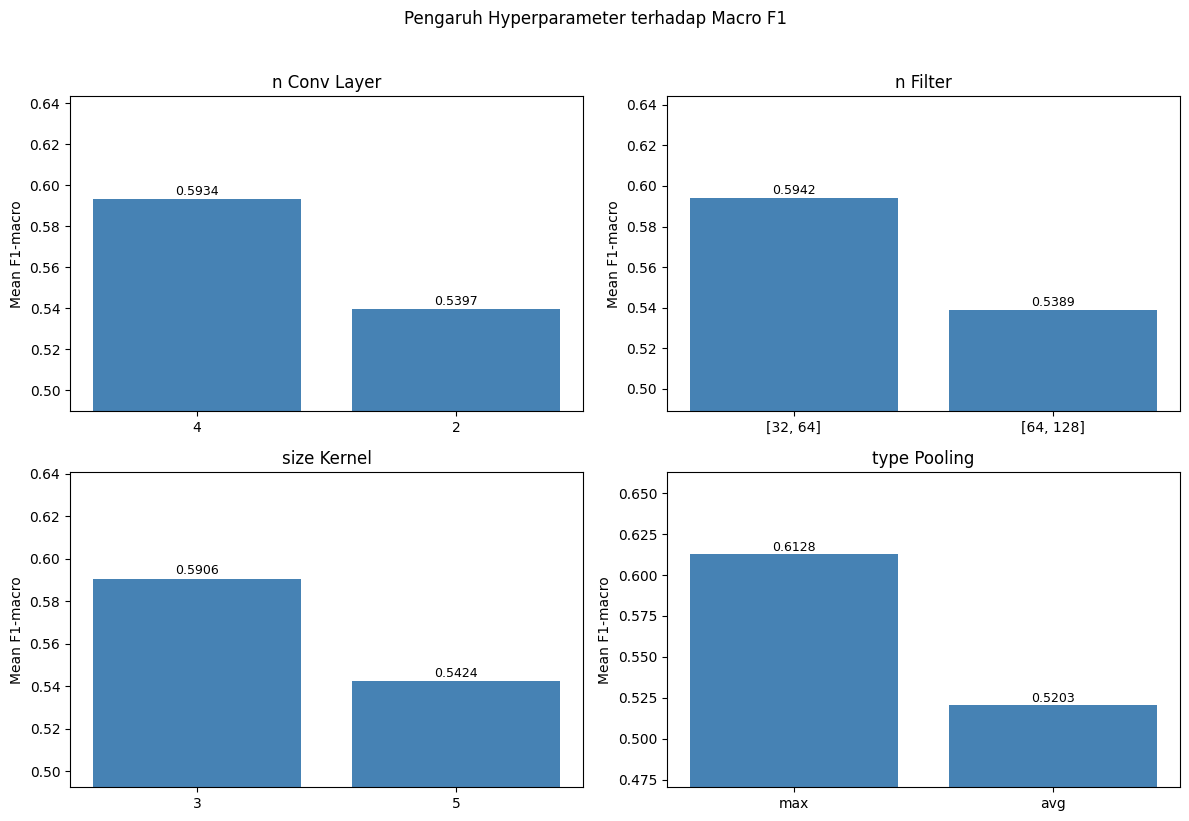

In [11]:
# Rata-rata F1 per nilai hyperparameter
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
hparams   = [('n_conv','n Conv Layer'), ('filters','n Filter'),
             ('k_size','size Kernel'), ('pool','type Pooling')]

for ax, (col, title) in zip(axes.flat, hparams):
    grp = df.groupby(col)['f1_macro'].mean().sort_values(ascending=False)

    ax.bar(grp.index.astype(str), grp.values, color='steelblue')
    ax.set_title(title)
    ax.set_ylabel('Mean F1-macro')
    ax.set_ylim(max(0, (grp.min()-0.05)), (grp.max()+0.05))

    for j, (x, v) in enumerate(zip(grp.index.astype(str), grp.values)):
        ax.text(j, v + 0.002, f'{v:.4f}', ha='center', fontsize=9)

plt.suptitle('Pengaruh Hyperparameter terhadap Macro F1', y=1.02)
plt.tight_layout()
plt.savefig(MODEL_DIR / 'hyperparam_analysis.png', bbox_inches='tight')
plt.show()

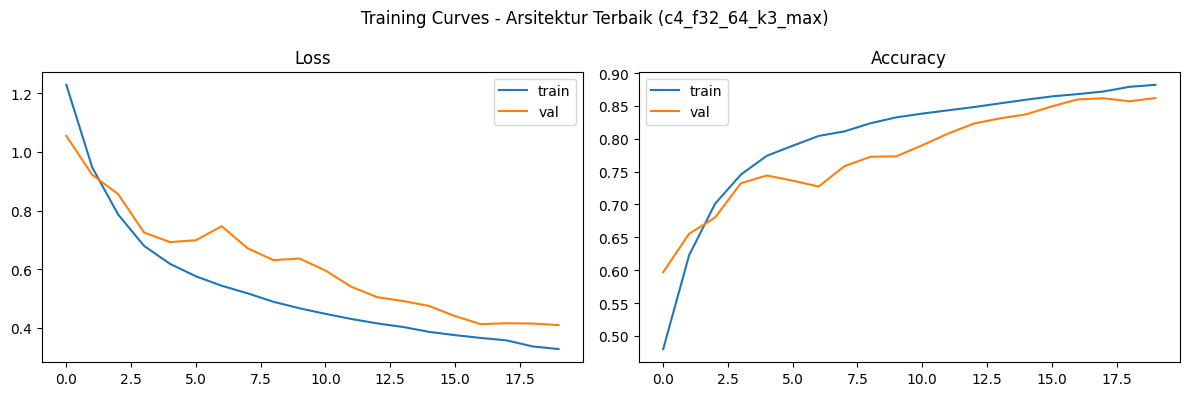

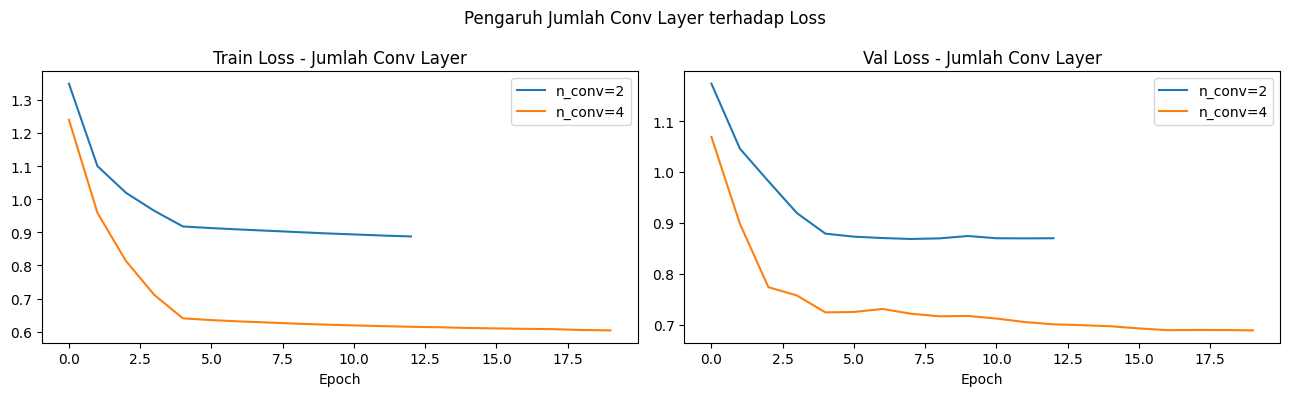

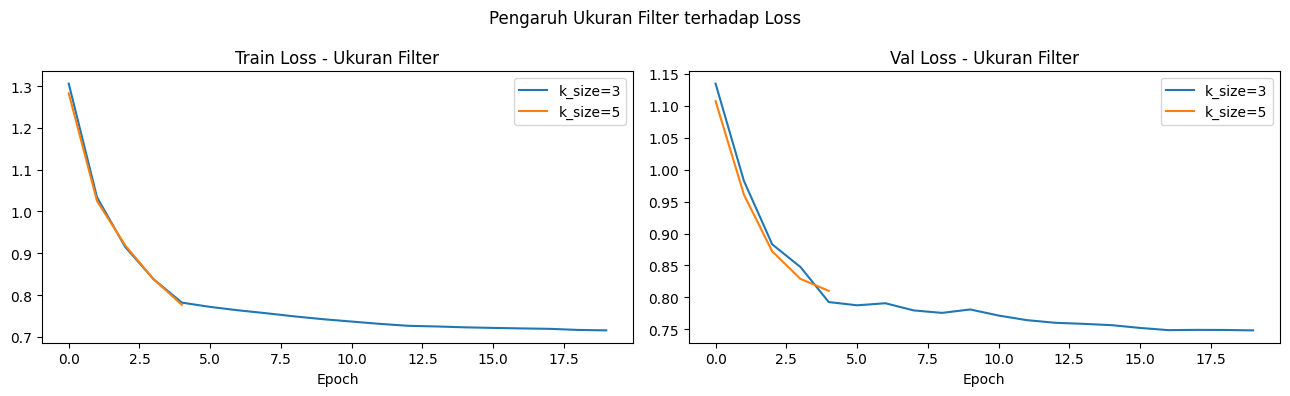

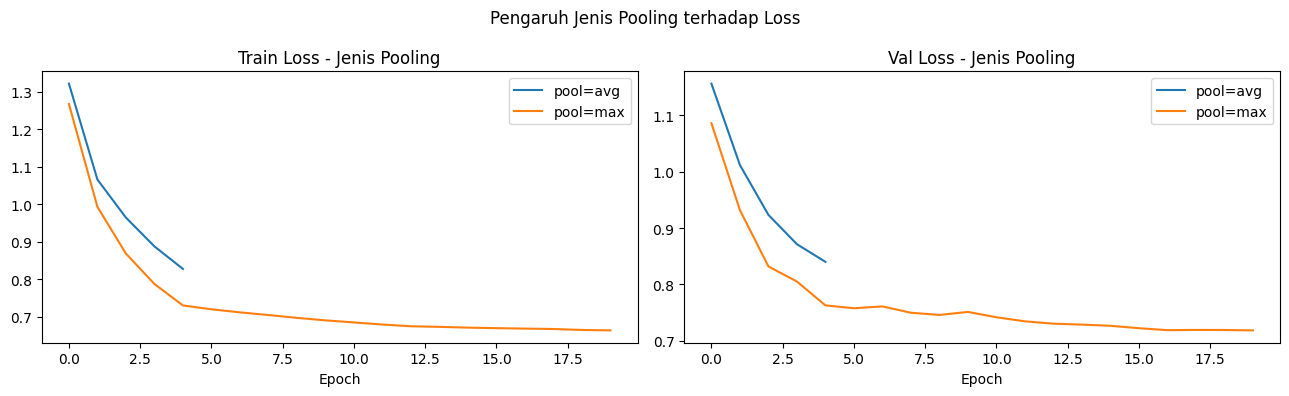

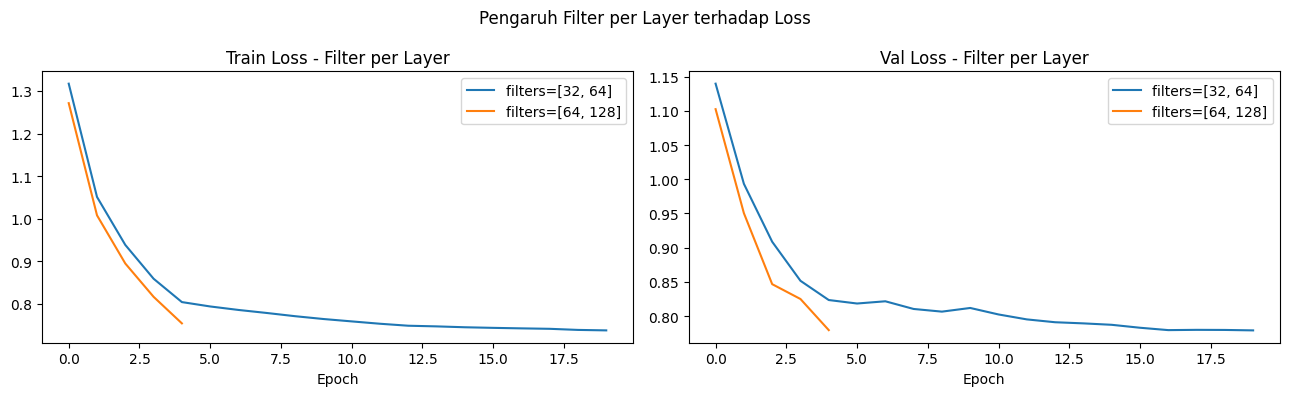

In [12]:
HIST_PATH = MODEL_DIR / 'histories.json'
if HIST_PATH.exists():
    with open(HIST_PATH) as fp:
        history.update(json.load(fp))

best_tag = best_row['tag']
if best_tag in history:
    hist = history[best_tag]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(hist['loss'], label='train')
    ax1.plot(hist['val_loss'], label='val')
    ax1.set_title('Loss')
    ax1.legend()

    ax2.plot(hist['accuracy'], label='train')
    ax2.plot(hist['val_accuracy'], label='val')
    ax2.set_title('Accuracy')
    ax2.legend()

    plt.suptitle(f'Training Curves - Arsitektur Terbaik ({best_tag})')
    plt.tight_layout()
    plt.savefig(MODEL_DIR / 'best_curves.png', bbox_inches='tight')
    plt.show()

else:
    print("Tidak memiliki history")


if history:

    hparam_groups = {
        'n_conv':  {'label': 'Jumlah Conv Layer', 'vals': sorted({result['n_conv'] for result in result_list})},
        'k_size':  {'label': 'Ukuran Filter', 'vals': sorted({result['k_size'] for result in result_list})},
        'pool':    {'label': 'Jenis Pooling', 'vals': sorted({result['pool'] for result in result_list})},
        'filters': {'label': 'Filter per Layer', 'vals': sorted({result['filters'] for result in result_list})},
    }

    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

    for param, info in hparam_groups.items():
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

        for ci, val in enumerate(info['vals']):
            subset = []
            for result in result_list:
                if str(result[param]) == str(val):
                    subset.append(result)

            all_vl = []
            all_tl = []
            for s in subset:
                if s['tag'] in history:
                    vl = history[s['tag']]['val_loss']
                    tl = history[s['tag']]['loss']

                    all_vl.append(vl)
                    all_tl.append(tl)

            if not all_vl:
                continue
            
            max_e = 0
            for vl in all_vl:
                len_vl = len(vl)

                if (len_vl > max_e):
                    max_e = len_vl
                    
            pad = lambda arr: [v + [v[-1]] * (max_e - len(v)) for v in arr]
            mean_vl = np.array(pad(all_vl)).mean(axis=0)
            mean_tl = np.array(pad(all_tl)).mean(axis=0)

            c = colors[ci % len(colors)]
            ax1.plot(mean_tl, label=f'{param}={val}', color=c)
            ax2.plot(mean_vl, label=f'{param}={val}', color=c)

        ax1.set_title(f'Train Loss - {info["label"]}'); ax1.legend(); ax1.set_xlabel('Epoch')
        ax2.set_title(f'Val Loss - {info["label"]}');   ax2.legend(); ax2.set_xlabel('Epoch')
        plt.suptitle(f'Pengaruh {info["label"]} terhadap Loss')

        plt.tight_layout()
        plt.savefig(MODEL_DIR / f'loss_curves_{param}.png', bbox_inches='tight')
        plt.show()

else:
    print('Tidak ada history tersimpan.')


### 4. Keras v. From-Scratch

In [13]:
from src.cnn.model import CNNFromScratch

best_path  = MODEL_DIR / f'arch_{best_row["idx"]:02d}_{best_tag}.h5'
keras_model = tf.keras.models.load_model(best_path)

X_test_np = np.concatenate([x.numpy() for x, _ in test_ds])
print(f'X_test shape: {X_test_np.shape}')

# 1. Keras
time_start = time.time()

y_keras = keras_model.predict(test_ds, verbose=0).argmax(1)
t_keras = time.time() - time_start
f1_keras = f1_score(y_test, y_keras, average='macro')


# 2. Scracth
scratch = CNNFromScratch.from_keras(keras_model)
time_start = time.time()

y_scratch = scratch.predict_classes(X_test_np)
t_scratch = time.time() - time_start
f1_scratch = f1_score(y_test, y_scratch, average='macro')

print(f'\n{"":20s} {"F1-macro":>10s} {"Waktu (s)":>10s}')
print(f'{"Keras":20s} {f1_keras:>10.4f} {t_keras:>10.2f}')
print(f'{"From-Scratch":20s} {f1_scratch:>10.4f} {t_scratch:>10.2f}')
print(f'\nPrediksi identik: {np.all(y_keras == y_scratch)}')


X_test shape: (3000, 100, 100, 3)
Model loaded: 11 layer aktif, 0 di-skip []

                       F1-macro  Waktu (s)
Keras                    0.8536       1.40
From-Scratch             0.8536      41.15

Prediksi identik: True


In [14]:
print('=== Keras ===')
print(classification_report(y_test, y_keras, target_names=CLASSES))
print('\n=== From-Scratch ===')
print(classification_report(y_test, y_scratch, target_names=CLASSES))

=== Keras ===
              precision    recall  f1-score   support

   buildings       0.84      0.84      0.84       437
      forest       0.98      0.94      0.96       474
     glacier       0.80      0.81      0.80       553
    mountain       0.80      0.82      0.81       525
         sea       0.86      0.81      0.84       510
      street       0.84      0.89      0.87       501

    accuracy                           0.85      3000
   macro avg       0.85      0.85      0.85      3000
weighted avg       0.85      0.85      0.85      3000


=== From-Scratch ===
              precision    recall  f1-score   support

   buildings       0.84      0.84      0.84       437
      forest       0.98      0.94      0.96       474
     glacier       0.80      0.81      0.80       553
    mountain       0.80      0.82      0.81       525
         sea       0.86      0.81      0.84       510
      street       0.84      0.89      0.87       501

    accuracy                           0.

### 5. Conv2D v. LocallyConnected2D

In [15]:
IMG_SIZE_LC2D = 32

# 1. Train
train_split_LC2D = tf.keras.utils.image_dataset_from_directory(TRAIN_DIR, 
                                                           image_size = (IMG_SIZE_LC2D, IMG_SIZE_LC2D),
                                                           batch_size = BATCH_SIZE,
                                                           label_mode = 'int',
                                                           seed = 42,
                                                           class_names = CLASSES,
                                                           )

# 2. Test
test_split_LC2D = tf.keras.utils.image_dataset_from_directory(TEST_DIR,
                                                           image_size = (IMG_SIZE_LC2D, IMG_SIZE_LC2D),
                                                           batch_size = BATCH_SIZE,
                                                           label_mode = 'int',
                                                           shuffle = False,
                                                           class_names = CLASSES,
                                                           )

train_ds_LC2D = train_split_LC2D.map(lambda x,y: (norm(x), y)).cache().prefetch(tf.data.AUTOTUNE)
test_ds_LC2D  = test_split_LC2D.map(lambda x,y: (norm(x), y)).cache().prefetch(tf.data.AUTOTUNE)

label_list_LC2D = []
for gambar, label in test_ds_LC2D:
    label_numpy = label.numpy()

    label_list_LC2D.append(label_numpy)

y_test_LC2D= np.concatenate(label_list_LC2D)

Found 14034 files belonging to 6 classes.
Found 3000 files belonging to 6 classes.


In [26]:
class LocallyConnected2D(tf.keras.layers.Layer):
    def __init__(self, filters, kernel_size, activation=None, **kwargs):
        super().__init__(**kwargs)
        self.filters = filters
        
        if isinstance(kernel_size, (list, tuple)):
            self.kernel_size = (int(kernel_size[0]), int(kernel_size[1]))
        else:
            self.kernel_size = (int(kernel_size), int(kernel_size))
        self.activation = tf.keras.activations.get(activation)

    def build(self, input_shape):
        _, h, w, c = input_shape
        kh, kw = self.kernel_size
        self.out_h = int(h) - kh + 1
        self.out_w = int(w) - kw + 1
        self.kernel = self.add_weight(
            shape=(self.out_h, self.out_w, kh * kw * int(c), self.filters),
            initializer='glorot_uniform', trainable=True, name='kernel'
        )
        self.bias = self.add_weight(
            shape=(self.out_h, self.out_w, self.filters),
            initializer='zeros', trainable=True, name='bias'
        )

    def call(self, inputs):
        kh, kw = self.kernel_size
        patches = tf.image.extract_patches(
            inputs,
            sizes=[1, kh, kw, 1], strides=[1, 1, 1, 1],
            rates=[1, 1, 1, 1], padding='VALID'
        )
        return self.activation(tf.einsum('bhwc,hwcf->bhwf', patches, self.kernel) + self.bias)

    def get_config(self):
        config = super().get_config()
        config.update({'filters': self.filters, 'kernel_size': list(self.kernel_size),
                       'activation': tf.keras.activations.serialize(self.activation)})
        return config


def build_LC2D(n_conv, filters, k_size, pool, img_size):
    if pool == 'max':
        PoolLayer = tf.keras.layers.MaxPooling2D
    else:
        PoolLayer = tf.keras.layers.AveragePooling2D

    name_model = f'lc2D_c{n_conv}_k{k_size}_{pool}'
    model = tf.keras.Sequential(name=name_model)
    model.add(tf.keras.layers.Input(shape=(img_size, img_size, 3)))

    for i in range(n_conv):
        fltr = filters[i % len(filters)]
        model.add(LocallyConnected2D(fltr, k_size, activation='relu'))
        model.add(PoolLayer(2, 2))

    model.add(tf.keras.layers.GlobalAveragePooling2D())
    model.add(tf.keras.layers.Dense(128, activation='relu'))
    model.add(tf.keras.layers.Dense(NUM_CLASSES, activation='softmax'))

    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [27]:
n_conv_best  = int(best_row['n_conv'])
filters_best = eval(best_row['filters'])
k_size_best  = int(best_row['k_size'])
pool_best    = best_row['pool']


min_lc2d_size = (2 ** n_conv_best - 1) * k_size_best + 1
if min_lc2d_size > IMG_SIZE_LC2D:
    print(f'IMG_SIZE_LC2D perlu dinaikkan: {IMG_SIZE_LC2D} → {min_lc2d_size} (n={n_conv_best}, k={k_size_best})')
    IMG_SIZE_LC2D = min_lc2d_size

    train_split_LC2D = tf.keras.utils.image_dataset_from_directory(
        TRAIN_DIR, image_size=(IMG_SIZE_LC2D, IMG_SIZE_LC2D),
        batch_size=BATCH_SIZE, label_mode='int', seed=42, class_names=CLASSES)
    test_split_LC2D  = tf.keras.utils.image_dataset_from_directory(
        TEST_DIR,  image_size=(IMG_SIZE_LC2D, IMG_SIZE_LC2D),
        batch_size=BATCH_SIZE, label_mode='int', shuffle=False, class_names=CLASSES)

    train_ds_LC2D = train_split_LC2D.map(lambda x,y: (norm(x), y)).cache().prefetch(tf.data.AUTOTUNE)
    test_ds_LC2D  = test_split_LC2D.map(lambda x,y: (norm(x), y)).cache().prefetch(tf.data.AUTOTUNE)

    label_list_LC2D = [label.numpy() for _, label in test_ds_LC2D]
    y_test_LC2D = np.concatenate(label_list_LC2D)
    print(f'Dataset LC2D dibuat ulang dengan ukuran {IMG_SIZE_LC2D}x{IMG_SIZE_LC2D}')
else:
    print(f'IMG_SIZE_LC2D={IMG_SIZE_LC2D} cukup untuk n={n_conv_best}, k={k_size_best}')

lc2D_model = build_LC2D(n_conv_best, filters_best, k_size_best, pool_best, img_size=IMG_SIZE_LC2D)
lc2D_model.summary()

def build_cnn_custom_size(n_conv, filters, k_size, pool, img_size):
    if pool == 'max':
        PoolLayer = tf.keras.layers.MaxPooling2D
    else:
        PoolLayer = tf.keras.layers.AveragePooling2D

    model = tf.keras.Sequential(name='conv2D_32x32')
    model.add(tf.keras.layers.Input(shape=(img_size, img_size, 3)))

    for i in range(n_conv):
        fltr = filters[i % len(filters)]
        model.add(tf.keras.layers.Conv2D(fltr, k_size, activation='relu', padding='same'))
        model.add(PoolLayer(2, 2))

    model.add(tf.keras.layers.GlobalAveragePooling2D())
    model.add(tf.keras.layers.Dense(128, activation='relu'))
    model.add(tf.keras.layers.Dense(NUM_CLASSES, activation='softmax'))

    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

conv2D_32x32 = build_cnn_custom_size(n_conv_best, filters_best, k_size_best, pool_best, IMG_SIZE_LC2D)
conv2D_32x32.summary()

IMG_SIZE_LC2D=46 cukup untuk n=4, k=3


Model: "lc2D_c4_k3_max"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ locally_connected2d_12          │ (None, 44, 44, 32)     │     1,734,656 │
│ (LocallyConnected2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_48 (MaxPooling2D) │ (None, 22, 22, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ locally_connected2d_13          │ (None, 20, 20, 64)     │     7,398,400 │
│ (LocallyConnected2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_49 (MaxPooling2D) │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ locally_connected2d_14          │ (None, 8, 8, 32)       │     1,181,696 │
│ (LocallyConnected2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_50 (MaxPooling2D) │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ locally_connected2d_15          │ (None, 2, 2, 64)       │        73,984 │
│ (LocallyConnected2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_51 (MaxPooling2D) │ (None, 1, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_22     │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,397,830 (39.66 MB)

 Trainable params: 10,397,830 (39.66 MB)

...

Model: "conv2D_32x32"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_60 (Conv2D)              │ (None, 46, 46, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_52 (MaxPooling2D) │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_61 (Conv2D)              │ (None, 23, 23, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_53 (MaxPooling2D) │ (None, 11, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_62 (Conv2D)              │ (None, 11, 11, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_54 (MaxPooling2D) │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_63 (Conv2D)              │ (None, 5, 5, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_55 (MaxPooling2D) │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_23     │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,446 (255.65 KB)

 Trainable params: 65,446 (255.65 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
lc2d_save = MODEL_DIR / f'lc2d_best_{IMG_SIZE_LC2D}.keras'
conv2D_32x32_save = MODEL_DIR / f'conv2d_{IMG_SIZE_LC2D}x{IMG_SIZE_LC2D}_best.keras'

for model, path, dataset in [(conv2D_32x32, conv2D_32x32_save, train_ds_LC2D),
                              (lc2D_model,   lc2d_save,         train_ds_LC2D)]:
    name = model.name

    if path.exists():
        print(f'{name} is loaded')
        if 'lc2D' in name or 'lc2d' in name.lower():
            loaded = tf.keras.models.load_model(path, custom_objects={'LocallyConnected2D': LocallyConnected2D})
        else:
            loaded = tf.keras.models.load_model(path)
        model.set_weights(loaded.get_weights())
    else:
        print(f'Training model: {name}')
        hist = model.fit(dataset, epochs=EPOCHS, validation_data=test_ds_LC2D, callbacks=[early_stop], verbose=0)
        model.save(path)
        history[name] = hist.history
        print(f' Done, went through ({len(hist.history["loss"])} epochs)')

conv2D_32x32 is loaded
lc2D_c4_k3_max is loaded


In [29]:
if conv2D_32x32_save.exists():
    conv2D_32x32 = tf.keras.models.load_model(conv2D_32x32_save)

if lc2d_save.exists():
    lc2D_model = tf.keras.models.load_model(
        lc2d_save,
        custom_objects={'LocallyConnected2D': LocallyConnected2D}
    )

y_conv2D_32x32 = conv2D_32x32.predict(test_ds_LC2D, verbose=0).argmax(1)
y_LC2D = lc2D_model.predict(test_ds_LC2D, verbose=0).argmax(1)

f1_conv2D_32x32 = f1_score(y_test_LC2D, y_conv2D_32x32, average='macro')
f1_LC2D    = f1_score(y_test_LC2D, y_LC2D,     average='macro')

print(f'\n{"":25s} {"F1-macro":>10s} {"Params":>12s}')
print(f'{"Conv2D (32x32)":25s} {f1_conv2D_32x32:>10.4f} {conv2D_32x32.count_params():>12,}')
print(f'{"LC2D   (32x32)":25s} {f1_LC2D:>10.4f} {lc2D_model.count_params():>12,}')


                            F1-macro       Params
Conv2D (32x32)                0.6485       65,446
LC2D   (32x32)                0.4451   10,397,830


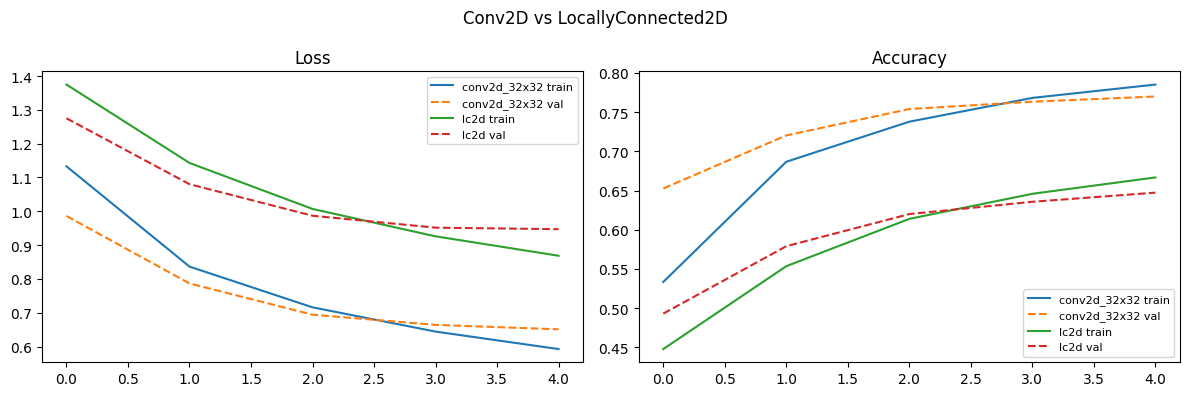

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for name, hist in [('conv2d_32x32', history.get('conv2D_32x32')),
                   ('lc2d', history.get(lc2D_model.name))
                   ]:
    
    if hist is None:
        continue

    axes[0].plot(hist['loss'],      label=f'{name} train')
    axes[0].plot(hist['val_loss'],  label=f'{name} val', linestyle='--')
    axes[1].plot(hist['accuracy'],     label=f'{name} train')
    axes[1].plot(hist['val_accuracy'], label=f'{name} val', linestyle='--')

axes[0].set_title('Loss'); axes[0].legend(fontsize=8)
axes[1].set_title('Accuracy'); axes[1].legend(fontsize=8)
plt.suptitle('Conv2D vs LocallyConnected2D')
plt.tight_layout()
plt.savefig(MODEL_DIR / 'conv_vs_lc2d.png', bbox_inches='tight')
plt.show()

### 6. Visualisasi Fitur

#### 6A. Intermediate Feature Maps (From-Scratch)

True class: buildings  |  shape: (100, 100, 3)
Model loaded: 11 layer aktif, 0 di-skip []


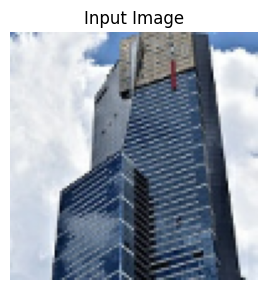

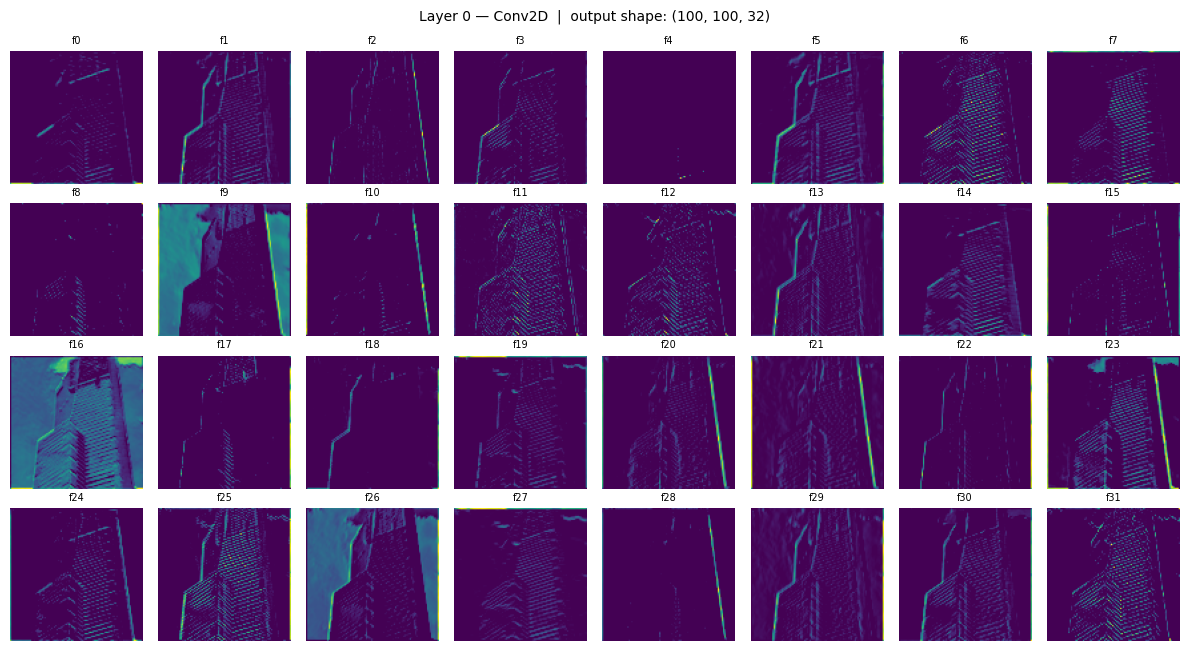

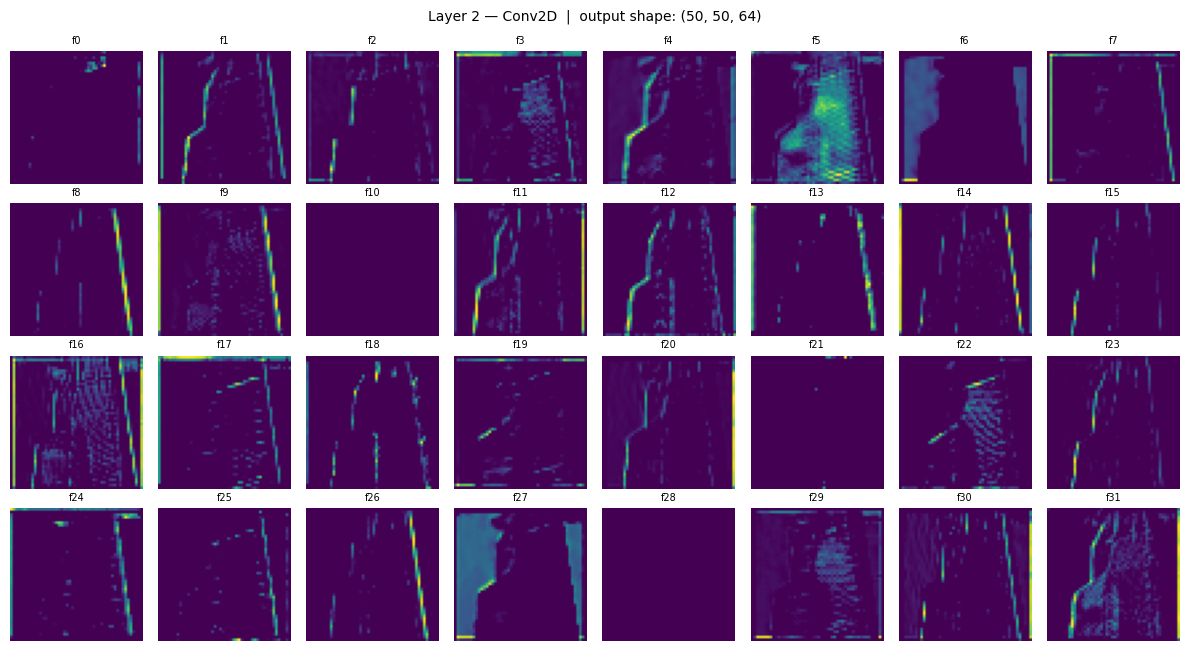

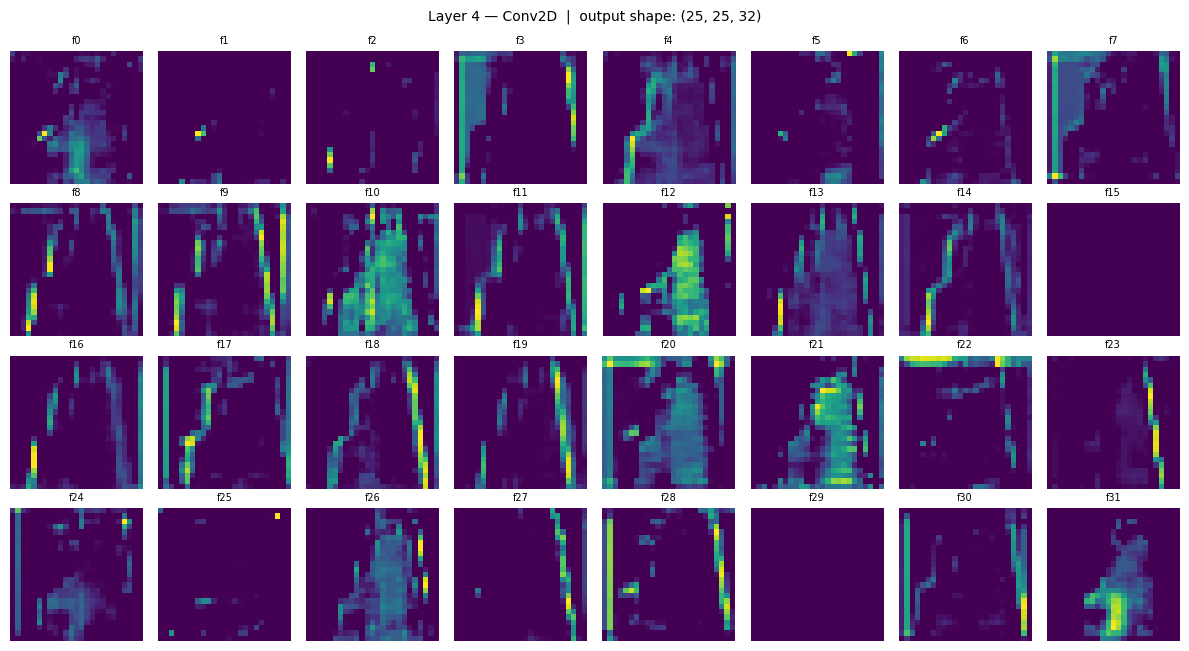

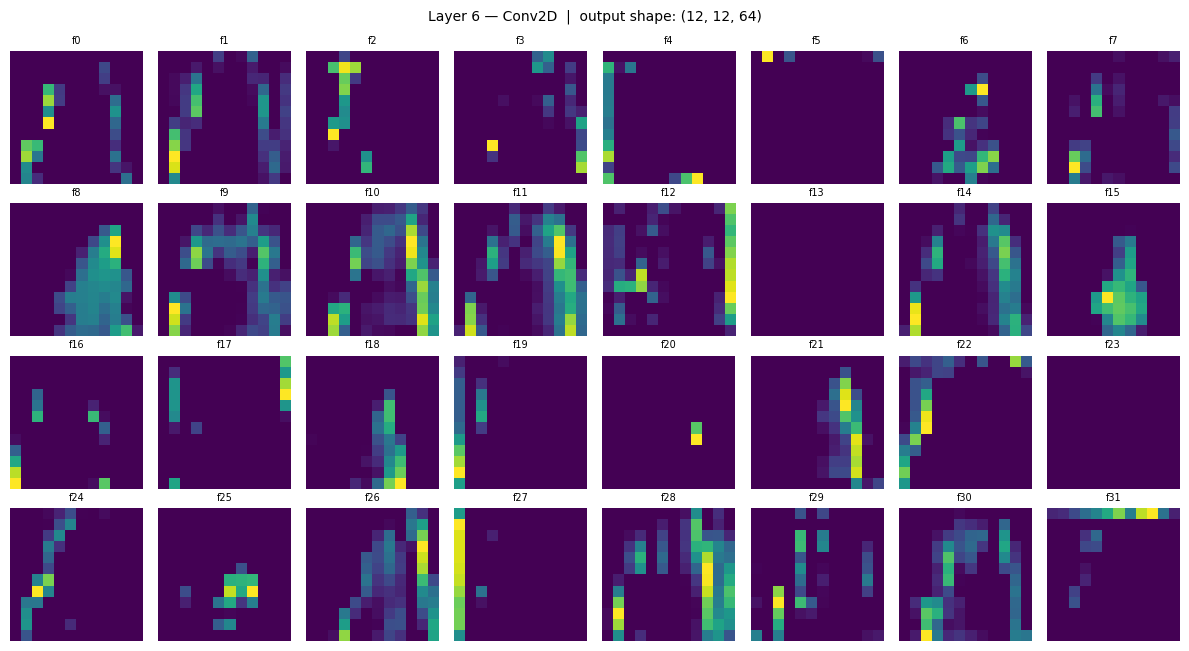

In [39]:
sample_img, sample_label = next(iter(test_ds))
img_np = sample_img[0].numpy()        
true_class = CLASSES[int(sample_label[0].numpy())]
print(f'True class: {true_class}  |  shape: {img_np.shape}')

# Load model terbaik 
best_path = MODEL_DIR / f'arch_{best_row["idx"]:02d}_{best_tag}.h5'
keras_best = tf.keras.models.load_model(best_path)
scratch_best = CNNFromScratch.from_keras(keras_best)

plot_feature_maps(scratch_best, img_np, max_filters=32)

#### 6B. Grad-CAM (Keras Model)

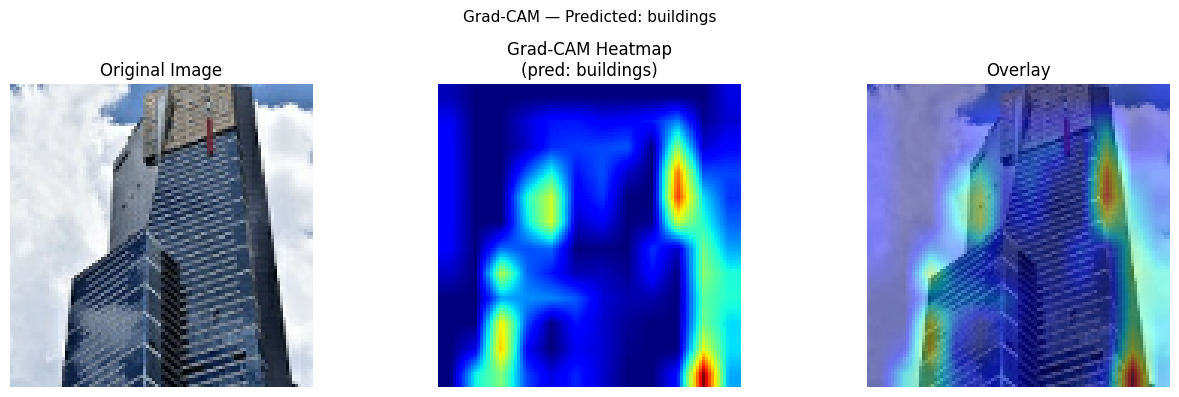

(array([[0.04909161, 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.08866045],
        [0.107538  , 0.        , 0.        , 0.07697055, 0.14069942,
         0.147461  , 0.10736701, 0.12143432, 0.14467137, 0.2571027 ,
         0.02067963, 0.07404204],
        [0.11860334, 0.        , 0.        , 0.06037019, 0.1638652 ,
         0.18258406, 0.19373393, 0.20983376, 0.        , 0.5231968 ,
         0.07349249, 0.12615821],
        [0.12005997, 0.        , 0.        , 0.20504686, 0.38398644,
         0.13604756, 0.20475951, 0.06382728, 0.        , 0.7998068 ,
         0.20185332, 0.18987302],
        [0.11979838, 0.        , 0.        , 0.38503745, 0.5929939 ,
         0.10128086, 0.17802808, 0.        , 0.        , 0.86169755,
         0.34471938, 0.17535536],
        [0.11737253, 0.        , 0.        , 0.3414754 , 0.6029598 ,
         0.0624944 , 0.10753869, 0.        , 0.01640771, 0.5845652 ,
  

In [40]:
# Grad-CAM 
plot_grad_cam(keras_best, img_np, class_names=CLASSES)

#### 6C. Grad-CAM Grid - Satu Gambar per Kelas

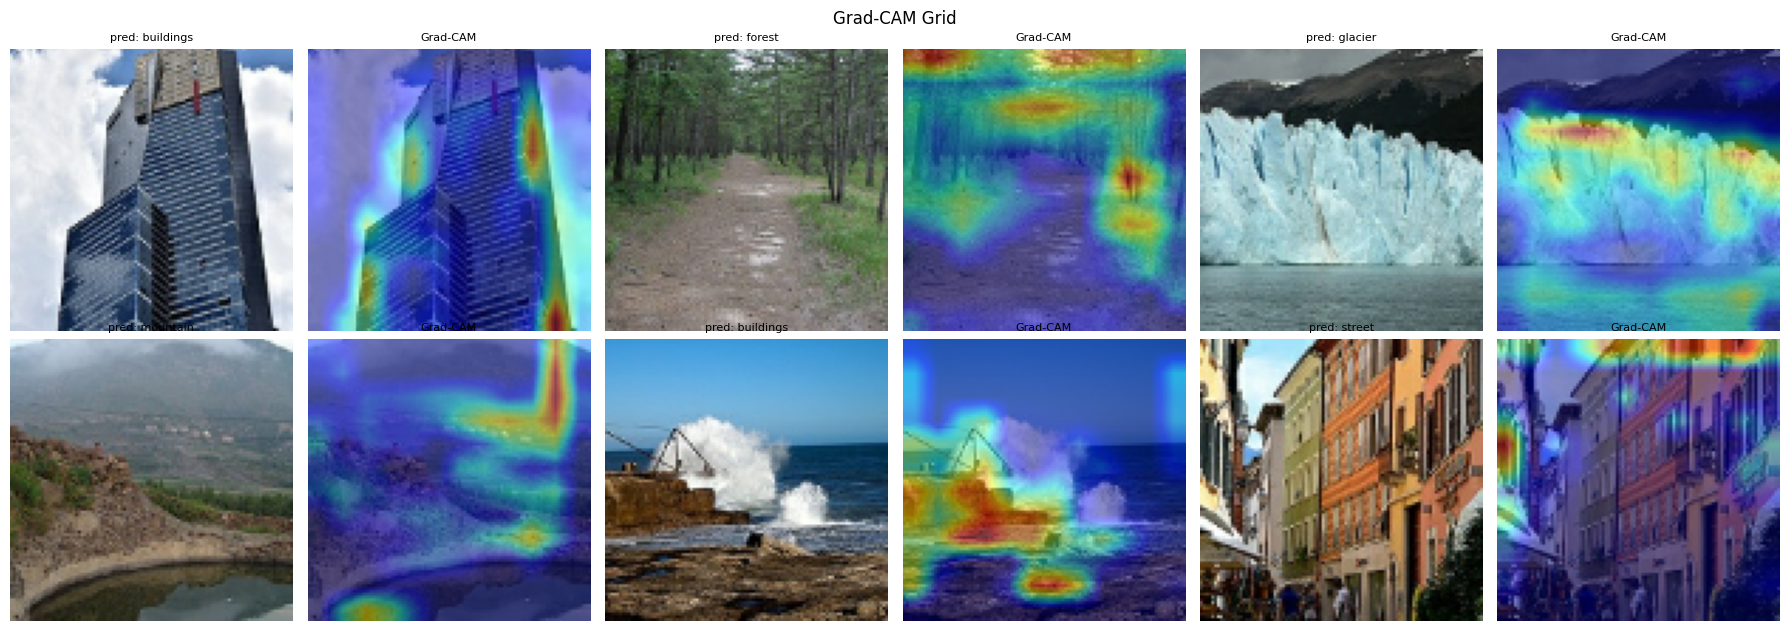

In [41]:
samples_per_class = {}
for imgs, labels in test_ds:
    for img, lbl in zip(imgs.numpy(), labels.numpy()):
        cls = int(lbl)
        if cls not in samples_per_class:
            samples_per_class[cls] = img
        if len(samples_per_class) == NUM_CLASSES:
            break
    if len(samples_per_class) == NUM_CLASSES:
        break

grid_images = [samples_per_class[i] for i in range(NUM_CLASSES)]
plot_grad_cam_grid(keras_best, grid_images, class_names=CLASSES, n_cols=3)